# Comprehensive Demosaicing Strategy Validation

**Date:** 2026-01-21

**Objective:** Systematically evaluate all demosaicing strategies and processing orders to determine which approach best recovers the ground truth photoelectron image from Bayer-patterned sCMOS camera data.

**Test Matrix:** 8 methods (4 strategies × 2 processing orders)

**Planning Document:** `claude/Demosaic_Testing_Strategies.md`

---

## Strategy

### Processing Orders

**Variance-Aware (Convert First):**
- ADU → Photoelectrons → Weight by variance → Demosaic
- Correct handling of spatially-varying gain

**Non-Variance-Aware (Demosaic First):**
- ADU → Demosaic → Convert to photoelectrons
- Mixes ADU values with different gains before conversion

### Demosaicing Algorithms
1. **malvar** - Malvar2004 (high quality, standard)
2. **bilinear** - Bilinear (simple, fast)
3. **ddfapd** - DDFAPD (edge-aware)
4. **menon2007** - Menon2007 (color artifact reduction)

### Ground Truth
- Use `gen_camera_image_stack(return_normal_image=True, return_photoelectrons=True)`
- Generates ideal flat-QE photoelectron image (no Bayer pattern)
- This is the "perfect" reference for comparison

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import types
from pathlib import Path
from tqdm.notebook import tqdm
import pandas as pd
from scipy.stats import pearsonr

# Add src to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', '..', 'src'))

from Multicolour_Simulation_Functions import MultiC_Sim_Funcs
from sCMOSFunctions import sCMOS_Functions
from SpectralFunctions import Spectral_Funcs
from MaskFunctions import Mask_Functions
from IOFunctions import IO_Functions
from PlottingBase import PublicationPlotter as Plotter

plotter = Plotter()

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Imports complete")

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/notebooks/../logs/Constants_20260206_103926.log


✓ Imports complete


/tmp/ipykernel_2137107/486766124.py:22: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = Plotter()


## 1. Setup Camera Parameters and Simulation

In [2]:
# Simulation parameters
image_size = 256  # pixels
pixel_size = 69.0  # nm
n_molecules = 50  # molecules per frame
n_bootstrap = 1000  # bootstrap samples per photon count

# Photon count range to test (10 steps from 500 to 20,000)
photon_counts = np.logspace(np.log10(500), np.log10(20000), 10).astype(int)

print(f"Image size: {image_size}×{image_size} pixels")
print(f"Molecules per frame: {n_molecules}")
print(f"Bootstrap samples: {n_bootstrap}")
print(f"\nPhoton counts to test: {photon_counts}")

Image size: 256×256 pixels
Molecules per frame: 50
Bootstrap samples: 1000

Photon counts to test: [  499   753  1134  1709  2576  3881  5848  8810 13274 20000]


In [3]:
# Load real camera calibration from Ximea camera
IO = IO_Functions()
data_folder = "../Camera_Calibrations/Ximea_Camera/"

print(f"Loading camera calibration from {data_folder}...")
gain_full = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_full = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance_full = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise_full = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe_full = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

print(f"Full calibration map shape: {gain_full.shape}")

# Crop to 256x256 from center
h, w = gain_full.shape
center_y, center_x = h // 2, w // 2
half_size = image_size // 2

y_start = center_y - half_size
y_end = center_y + half_size
x_start = center_x - half_size
x_end = center_x + half_size

gain_map = gain_full[y_start:y_end, x_start:x_end]
offset_map = offset_full[y_start:y_end, x_start:x_end]
variance_map = variance_full[y_start:y_end, x_start:x_end]
readnoise_map = readnoise_full[y_start:y_end, x_start:x_end]
rqe_map = rqe_full[y_start:y_end, x_start:x_end]

print(f"Cropped to: {gain_map.shape}")

# Setup masks and spectral functions
M_F = Mask_Functions()
S_F = Spectral_Funcs()

masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

camera_parameters = {
    "gain": gain_map,
    "offset": offset_map,
    "variance": variance_map,
    "readnoise": readnoise_map,
    "rqe": rqe_map,
    "pixel_QYs": pixel_QYs,
    "pixel_order": ["B", "G", "R"],
    "pixel_order_indices": [0, 1, 2],
    "masks": masks,
}

print(f"\n✓ Real camera parameters loaded")
print(f"  Gain range: [{gain_map.min():.3f}, {gain_map.max():.3f}] ADU/pe")
print(f"  Gain mean: {gain_map.mean():.3f} ADU/pe")
print(f"  Gain std: {gain_map.std():.3f} ADU/pe")
print(f"  Offset range: [{offset_map.min():.1f}, {offset_map.max():.1f}] ADU")
print(f"  Offset mean: {offset_map.mean():.1f} ADU")
print(f"  Variance range: [{variance_map.min():.2f}, {variance_map.max():.2f}] ADU²")
print(f"  Variance mean: {variance_map.mean():.2f} ADU²")

Loading camera calibration from ../Camera_Calibrations/Ximea_Camera/...
Full calibration map shape: (1544, 2064)
Cropped to: (256, 256)

✓ Real camera parameters loaded
  Gain range: [0.390, 0.433] ADU/pe
  Gain mean: 0.414 ADU/pe
  Gain std: 0.006 ADU/pe
  Offset range: [30.3, 73.2] ADU
  Offset mean: 32.3 ADU
  Variance range: [0.75, 30.49] ADU²
  Variance mean: 0.96 ADU²


In [4]:
# Dye and PSF parameters - ATTO 565
dye_name = "ATTO 565"

# Load ATTO 565 emission spectrum from database
atto565_spectrum = S_F.get_dye_or_filter_data(dye_name, wavelength, dye_or_filter=True)

# Squeeze to 1D if needed
if atto565_spectrum.ndim > 1:
    atto565_spectrum = np.squeeze(atto565_spectrum)

# Normalize the spectrum
atto565_spectrum = atto565_spectrum / np.sum(atto565_spectrum)

# Calculate pixel efficiencies for B, G, R channels from the spectrum
average_emission_wavelength, dye_pixel_efficiency = S_F.get_pixel_fractions_rawspectra(
    wavelength=wavelength, 
    pixel_QYs=pixel_QYs, 
    spectra=atto565_spectrum
)

print(f"✓ Dye: {dye_name}")
print(f"  Average emission wavelength: {average_emission_wavelength:.1f} nm")
print(f"  Pixel efficiencies (B, G, R): [{dye_pixel_efficiency[0]:.3f}, {dye_pixel_efficiency[1]:.3f}, {dye_pixel_efficiency[2]:.3f}]")

# Other simulation parameters
background_photons = 10.0  # photons per pixel
NA = 1.49

# Setup smoothing function (PSF)
scmos = sCMOS_Functions()
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = scmos.gaussian_filter_stack
smoothing_function.data_arg = "image"

print(f"  Background: {background_photons} photons/pixel")
print(f"  NA: {NA}")
print(f"  PSF sigma: {smoothing_function.args['sigma']}")

✓ Dye: ATTO 565
  Average emission wavelength: 611.9 nm
  Pixel efficiencies (B, G, R): [0.024, 0.330, 0.494]
  Background: 10.0 photons/pixel
  NA: 1.49
  PSF sigma: 1.5


## 2. Define Simulation Function

In [5]:
def generate_test_simulation(n_photons_per_molecule, n_molecules=50):
    """
    Generate a single test simulation with ground truth.
    
    Args:
        n_photons_per_molecule: Number of photons per molecule
        n_molecules: Number of molecules to place in image
        
    Returns:
        bayer_adu: Bayer-patterned image in ADU (256, 256)
        ground_truth_pe: Ground truth photoelectron image (256, 256)
    """
    # Generate random molecule positions across the image
    # Keep molecules away from edges (20 pixel border)
    border = 20
    x_positions = np.random.uniform(
        border * pixel_size, 
        (image_size - border) * pixel_size, 
        n_molecules
    )
    y_positions = np.random.uniform(
        border * pixel_size, 
        (image_size - border) * pixel_size, 
        n_molecules
    )
    
    # Create x0y0 dictionary: shape (n_frames, 2, n_molecules)
    # 1 frame, 2 coordinates (x, y), n_molecules
    x0y0 = {'dye': np.zeros((1, 2, n_molecules))}
    x0y0['dye'][0, 0, :] = x_positions  # x positions (nm)
    x0y0['dye'][0, 1, :] = y_positions  # y positions (nm)
    
    # Single photon count value (scalar) - each molecule gets this many photons
    n_photons = {'dye': n_photons_per_molecule}
    
    # Generate simulation
    MSF = MultiC_Sim_Funcs()
    
    bayer_adu, _, ground_truth_pe = MSF.gen_camera_image_stack(
        camera_calibration=camera_parameters,
        wavelength=wavelength,
        average_emission_wavelengths=average_emission_wavelength,
        dye_pixel_efficiency=dye_pixel_efficiency,
        n_photons=n_photons,
        x0y0=x0y0,
        smoothing_function=smoothing_function,
        background_photons=background_photons,
        NA=NA,
        pixel_size=pixel_size,
        return_normal_image=True,
        return_photoelectrons=True,  # Ground truth in photoelectrons
    )
    
    return np.squeeze(bayer_adu), np.squeeze(ground_truth_pe)

# Test the function
test_bayer, test_gt = generate_test_simulation(2000, n_molecules=50)
print(f"✓ Simulation function working")
print(f"  Bayer image shape: {test_bayer.shape}")
print(f"  Ground truth shape: {test_gt.shape}")
print(f"  Bayer ADU range: [{test_bayer.min():.1f}, {test_bayer.max():.1f}]")
print(f"  Ground truth PE range: [{test_gt.min():.1f}, {test_gt.max():.1f}]")
print(f"  Number of molecules: 50 (spread across the image)")

✓ Simulation function working
  Bayer image shape: (256, 256)
  Ground truth shape: (256, 256)
  Bayer ADU range: [24.0, 74.0]
  Ground truth PE range: [0.0, 112.0]
  Number of molecules: 50 (spread across the image)


## 3. Define Demosaicing Methods

In [6]:
# Define all 8 methods to test
strategies = ['malvar', 'bilinear', 'menon2007']

def apply_variance_aware_demosaic(bayer_adu, strategy):
    """
    Variance-aware processing: Convert first, then demosaic.
    
    Order: ADU → Photoelectrons → Weight by variance → Demosaic
    """
    result = scmos.variance_aware_demosaic(
        CFA=bayer_adu,
        variance_map=variance_map,
        offset_map=offset_map,
        gain=gain_map,
        grayscale=True,
        strategy=strategy
    )
    return result

def apply_standard_demosaic(bayer_adu, strategy):
    """
    Non-variance-aware processing: Demosaic first, then convert.
    
    Order: ADU → Demosaic → Convert to photoelectrons
    """
    # Demosaic in ADU space
    rgb_adu, gray_adu = scmos.bayer_demosaic_stack(
        bayer_adu,
        grayscale=True,
        strategy=strategy
    )
    
    # Convert to photoelectrons (using mean gain since we already interpolated)
    # This is the problem: we mixed ADU values with different gains
    result = (gray_adu - offset_map) / gain_map
    return result

# Create method registry
methods = {}
for strategy in strategies:
    methods[f'{strategy}_varaware'] = lambda img, s=strategy: apply_variance_aware_demosaic(img, s)
    methods[f'{strategy}_standard'] = lambda img, s=strategy: apply_standard_demosaic(img, s)

print(f"✓ Defined {len(methods)} demosaicing methods:")
for method_name in methods.keys():
    print(f"  - {method_name}")

✓ Defined 6 demosaicing methods:
  - malvar_varaware
  - malvar_standard
  - bilinear_varaware
  - bilinear_standard
  - menon2007_varaware
  - menon2007_standard


## 4. Define Metrics Functions

In [7]:
def calculate_metrics(demosaiced, ground_truth):
    """
    Calculate comparison metrics between demosaiced and ground truth images.
    
    Returns:
        Dictionary of metrics
    """
    # Flatten for correlation calculation
    dem_flat = demosaiced.flatten()
    gt_flat = ground_truth.flatten()
    
    # Absolute error
    abs_error = np.abs(demosaiced - ground_truth)
    
    # Relative error (avoid division by zero)
    rel_error = np.zeros_like(abs_error)
    mask = ground_truth > 1.0  # Only calculate for signal pixels
    rel_error[mask] = abs_error[mask] / ground_truth[mask] * 100
    
    # RMSE
    rmse = np.sqrt(np.mean((demosaiced - ground_truth)**2))
    rmse_normalized = rmse / np.mean(ground_truth) * 100
    
    # Correlation
    corr, _ = pearsonr(dem_flat, gt_flat)
    
    # SNR comparison
    signal_mask = ground_truth > np.percentile(ground_truth, 90)  # Top 10% as signal
    if np.sum(signal_mask) > 10:  # Need enough pixels
        gt_snr = np.mean(ground_truth[signal_mask]) / np.std(ground_truth[~signal_mask])
        dem_snr = np.mean(demosaiced[signal_mask]) / np.std(demosaiced[~signal_mask])
        snr_ratio = dem_snr / gt_snr if gt_snr > 0 else np.nan
    else:
        snr_ratio = np.nan
    
    # Peak intensity recovery
    peak_gt = np.percentile(ground_truth, 99)
    peak_dem = np.percentile(demosaiced, 99)
    peak_recovery = peak_dem / peak_gt if peak_gt > 0 else np.nan
    
    return {
        'mae': np.mean(abs_error),
        'median_ae': np.median(abs_error),
        'mae_signal': np.mean(abs_error[mask]) if np.sum(mask) > 0 else np.nan,
        'rel_error_mean': np.mean(rel_error[mask]) if np.sum(mask) > 0 else np.nan,
        'rel_error_median': np.median(rel_error[mask]) if np.sum(mask) > 0 else np.nan,
        'rmse': rmse,
        'rmse_normalized': rmse_normalized,
        'correlation': corr,
        'snr_ratio': snr_ratio,
        'peak_recovery': peak_recovery,
    }

# Test metrics
test_result = apply_variance_aware_demosaic(test_bayer, 'bilinear')
test_metrics = calculate_metrics(test_result, test_gt)
print("✓ Metrics calculation working")
print("  Sample metrics:")
for key, val in test_metrics.items():
    print(f"    {key}: {val:.4f}")

✓ Metrics calculation working
  Sample metrics:
    mae: 12.3636
    median_ae: 6.0308
    mae_signal: 14.2230
    rel_error_mean: 136.6284
    rel_error_median: 90.3434
    rmse: 18.5370
    rmse_normalized: 150.6176
    correlation: 0.1781
    snr_ratio: 0.3943
    peak_recovery: 1.0143


## 5. Run Bootstrap Validation

This will test all methods across all photon counts with bootstrap resampling.

In [8]:
# Storage for all results
all_results = []

# Total iterations for progress bar
total_iterations = len(photon_counts) * n_bootstrap * len(methods)

print(f"Starting bootstrap validation...")
print(f"Total iterations: {total_iterations}")
print(f"  Photon counts: {len(photon_counts)}")
print(f"  Bootstrap samples per count: {n_bootstrap}")
print(f"  Methods: {len(methods)}")
print()

with tqdm(total=total_iterations, desc="Overall progress") as pbar:
    for n_photons in photon_counts:
        for i_boot in range(n_bootstrap):
            # Generate simulation
            bayer_img, ground_truth = generate_test_simulation(n_photons, n_molecules)
            
            # Test all methods
            for method_name, method_func in methods.items():
                # Apply demosaicing
                demosaiced = method_func(bayer_img)
                
                # Calculate metrics
                metrics = calculate_metrics(demosaiced, ground_truth)
                
                # Store results
                result = {
                    'n_photons': n_photons,
                    'bootstrap_idx': i_boot,
                    'method': method_name,
                    'strategy': method_name.split('_')[0],
                    'processing': 'variance_aware' if 'varaware' in method_name else 'standard',
                    **metrics
                }
                all_results.append(result)
                
                pbar.update(1)

# Convert to DataFrame for easier analysis
df_results = pd.DataFrame(all_results)

print(f"\n✓ Bootstrap validation complete!")
print(f"  Total results: {len(df_results)}")
print(f"\nDataFrame preview:")
print(df_results.head())

Starting bootstrap validation...
Total iterations: 60000
  Photon counts: 10
  Bootstrap samples per count: 1000
  Methods: 6



Overall progress:   0%|          | 0/60000 [00:00<?, ?it/s]


✓ Bootstrap validation complete!
  Total results: 60000

DataFrame preview:
   n_photons  bootstrap_idx              method   strategy      processing  \
0        499              0     malvar_varaware     malvar  variance_aware   
1        499              0     malvar_standard     malvar        standard   
2        499              0   bilinear_varaware   bilinear  variance_aware   
3        499              0   bilinear_standard   bilinear        standard   
4        499              0  menon2007_varaware  menon2007  variance_aware   

          mae   median_ae  mae_signal  rel_error_mean  rel_error_median  \
0   13.543253    8.226308   15.388826      187.087870        105.913500   
1  150.879463  156.288719  148.410256     3858.343208       3936.008651   
2   12.037560    5.998820   13.832580      136.805331         90.059238   
3  150.880005  157.654274  148.165201     3857.737878       3943.771483   
4   13.965206    8.814373   15.807236      199.580172        109.765636   

   

## 6. Aggregate Statistics

Calculate mean and confidence intervals across bootstrap samples.

In [9]:
# Group by method and photon count, calculate statistics
metric_cols = ['mae', 'rmse', 'rmse_normalized', 'correlation', 'snr_ratio', 'peak_recovery']

df_stats = df_results.groupby(['method', 'n_photons'])[metric_cols].agg(['mean', 'std', 'median'])

# Flatten column names
df_stats.columns = ['_'.join(col).strip() for col in df_stats.columns.values]
df_stats = df_stats.reset_index()

print("✓ Statistics aggregated")
print(f"\nSummary statistics (first few rows):")
print(df_stats.head(10))

✓ Statistics aggregated

Summary statistics (first few rows):
              method  n_photons    mae_mean   mae_std  mae_median   rmse_mean  \
0  bilinear_standard        499  150.821377  0.039072  150.821965  151.773212   
1  bilinear_standard        753  150.932312  0.040644  150.932473  151.892422   
2  bilinear_standard       1134  151.097869  0.040259  151.096953  152.077102   
3  bilinear_standard       1709  151.345438  0.039269  151.345953  152.368311   
4  bilinear_standard       2576  151.722475  0.039657  151.720206  152.844567   
5  bilinear_standard       3881  152.289172  0.040864  152.290574  153.635238   
6  bilinear_standard       5848  153.138893  0.041049  153.137631  154.990713   
7  bilinear_standard       8810  154.423991  0.042902  154.426014  157.411403   
8  bilinear_standard      13274  156.358414  0.045234  156.356454  161.853725   
9  bilinear_standard      20000  159.272021  0.045901  159.272416  170.199378   

   rmse_std  rmse_median  rmse_normalized_mean

In [10]:
method_array = np.unique(df_stats['method'])

In [11]:
info_columns = df_stats.columns[2:]

In [12]:
info_columns[0]

'mae_mean'

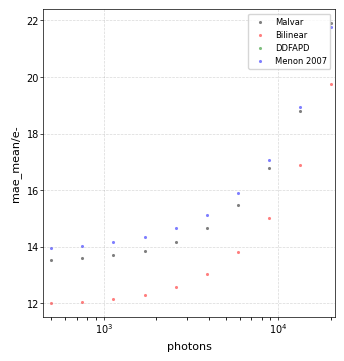

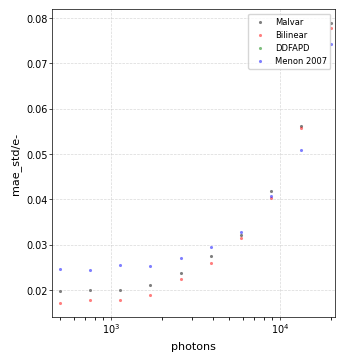

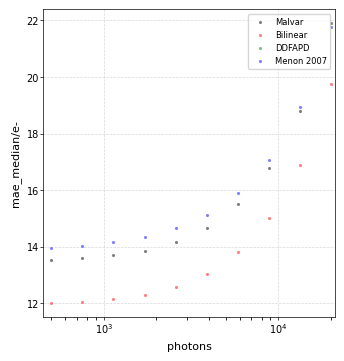

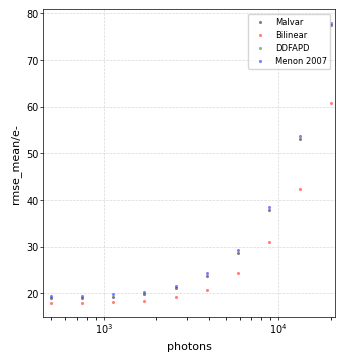

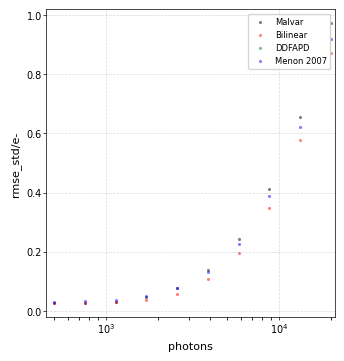

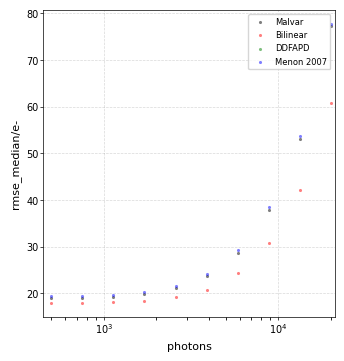

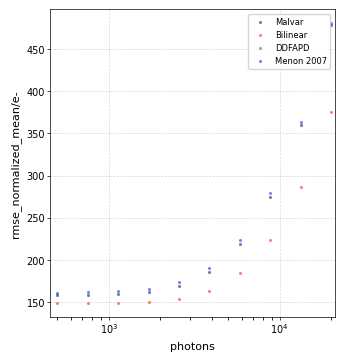

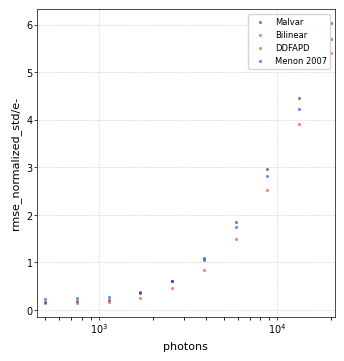

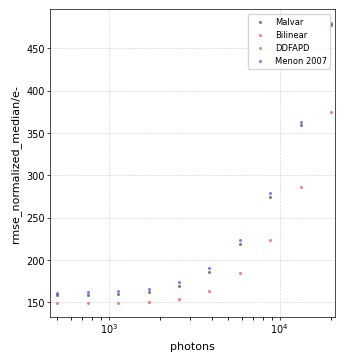

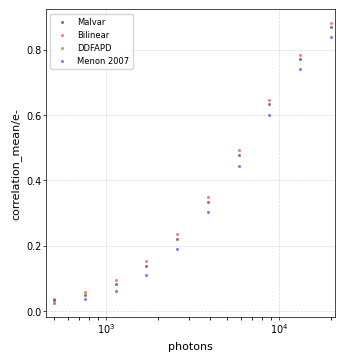

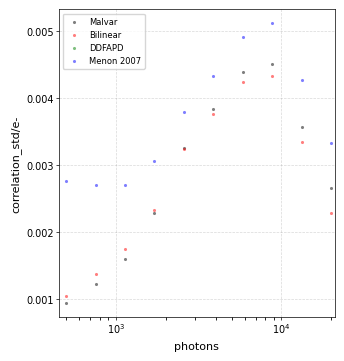

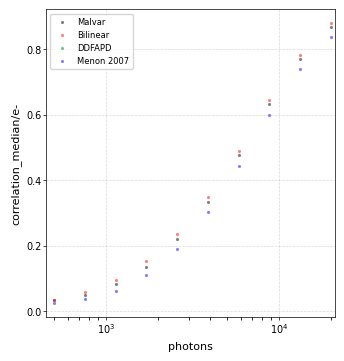

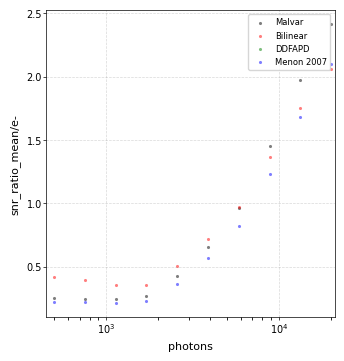

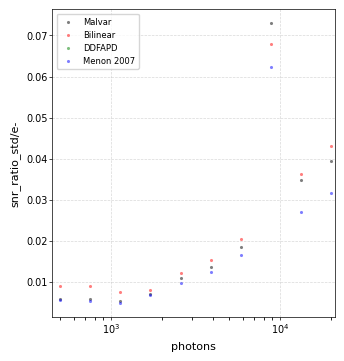

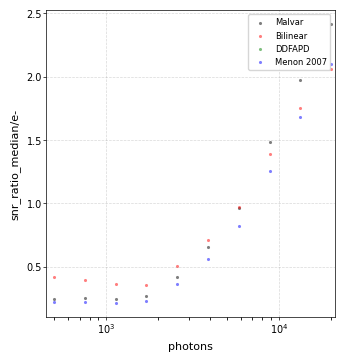

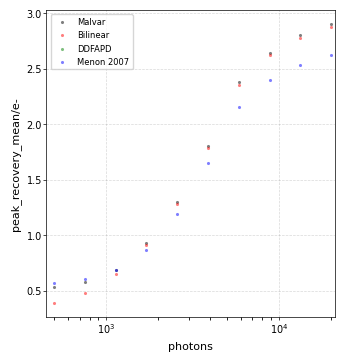

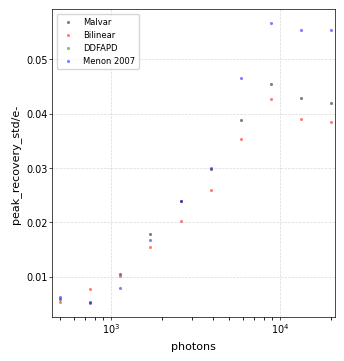

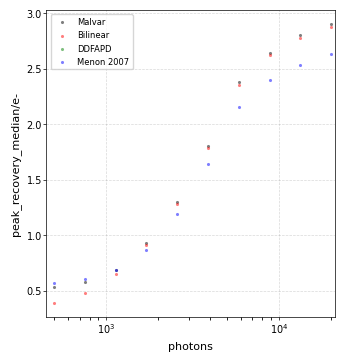

In [13]:
for column in info_columns:
    fig, axs = plotter.one_column_plot()

    axs = plotter.scatter_plot(axs, df_stats[df_stats['method'] == 'malvar_varaware']['n_photons'], 
                               df_stats[df_stats['method'] == 'malvar_varaware'][column], facecolor='black', alpha=0.5,
                              lw=0, label='Malvar')
    axs = plotter.scatter_plot(axs, df_stats[df_stats['method'] == 'bilinear_varaware']['n_photons'], 
                               df_stats[df_stats['method'] == 'bilinear_varaware'][column], facecolor='red', alpha=0.5,
                              lw=0, label='Bilinear')
    axs = plotter.scatter_plot(axs, df_stats[df_stats['method'] == 'ddfapd_varaware']['n_photons'],
                               df_stats[df_stats['method'] == 'ddfapd_varaware'][column], facecolor='green', alpha=0.5,
                              lw=0, label='DDFAPD')
    axs = plotter.scatter_plot(axs, df_stats[df_stats['method'] == 'menon2007_varaware']['n_photons'],
                               df_stats[df_stats['method'] == 'menon2007_varaware'][column], facecolor='blue', alpha=0.5,
                              lw=0, label='Menon 2007', xaxislabel='photons', yaxislabel=column+'/e-')

    axs.set_xlim([450, 21000])
    axs.legend(loc='best')
    axs.set_xscale('log')
    folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260205/fig/Demosaicing/'
    plt.savefig(os.path.join(folder, column+'_comparisonplot.svg'), dpi=600, format='svg')

## 7. Visualization: Method Comparison

### 7.1 RMSE vs Photon Count

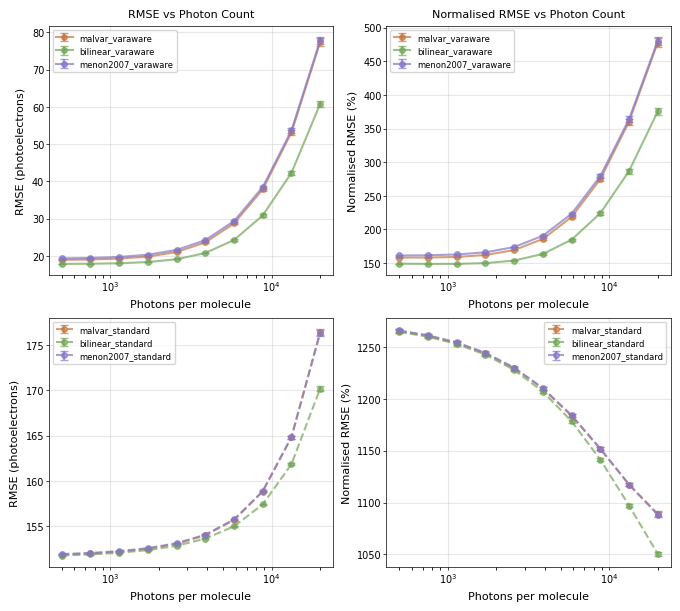

✓ RMSE comparison plotted


In [14]:
fig, axes = plotter.two_column_plot(ncolumns=2, nrows=2, widthratio=[1,1], heightratio=[1,1])

# Color scheme: one color per strategy, solid/dashed for processing order


colors = {'malvar': '#c6763f', 'bilinear': '#72a659', 'ddfapd': 'C2', 'menon2007': '#8377cb'}
linestyles = {'variance_aware': '-', 'standard': '--'}

for method in methods.keys():
    strategy = method.split('_')[0]
    processing = 'variance_aware' if 'varaware' in method else 'standard'
    if processing == 'variance_aware':
        row=0
    else:
        row=1
    
    data = df_stats[df_stats['method'] == method]
    
    # RMSE (absolute)
    axes[row, 0].errorbar(
        data['n_photons'],
        data['rmse_mean'],
        yerr=data['rmse_std'],
        label=method,
        color=colors[strategy],
        linestyle=linestyles[processing],
        marker='o',
        markersize=4,
        capsize=3,
        alpha=0.7
    )
    
    # RMSE (normalized %)
    axes[row, 1].errorbar(
        data['n_photons'],
        data['rmse_normalized_mean'],
        yerr=data['rmse_normalized_std'],
        label=method,
        color=colors[strategy],
        linestyle=linestyles[processing],
        marker='o',
        markersize=4,
        capsize=3,
        alpha=0.7
    )

for i in np.arange(2):
    axes[i, 0].set_xlabel('Photons per molecule')
    axes[i, 0].set_ylabel('RMSE (photoelectrons)')
    axes[i, 0].set_xscale('log')
    axes[i, 0].legend(fontsize=6, ncol=1)
    if i == 0:
        axes[i, 0].set_title('RMSE vs Photon Count')
    axes[i, 0].grid(True, alpha=0.3)
    
    axes[i, 1].set_xlabel('Photons per molecule')
    axes[i, 1].set_ylabel('Normalised RMSE (%)')
    axes[i, 1].set_xscale('log')
    axes[i, 1].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 1].set_title('Normalised RMSE vs Photon Count')
    axes[i, 1].legend(fontsize=6, ncol=1)
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260205/fig/Demosaicing/'
plt.savefig(os.path.join(folder, 'demosaic_comparison_rmse.svg'), dpi=600, format='svg')
plt.show()

print("✓ RMSE comparison plotted")

### 7.2 Correlation vs Photon Count

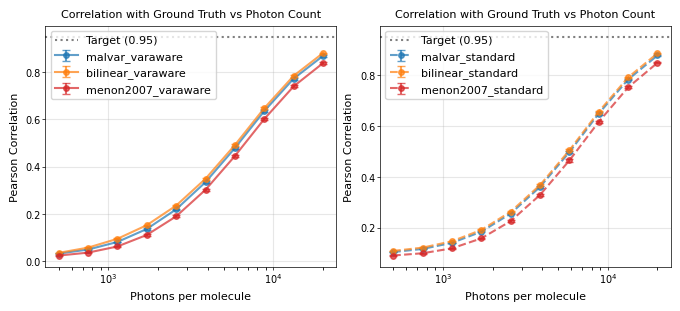

✓ Correlation comparison plotted


In [15]:
fig, axes = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

for method in methods.keys():
    strategy = method.split('_')[0]
    processing = 'variance_aware' if 'varaware' in method else 'standard'
    if processing == 'variance_aware':
        row=0
    else:
        row=1

    data = df_stats[df_stats['method'] == method]
    
    axes[row].errorbar(
        data['n_photons'],
        data['correlation_mean'],
        yerr=data['correlation_std'],
        label=method,
        color=colors[strategy],
        linestyle=linestyles[processing],
        marker='o',
        markersize=4,
        capsize=3,
        alpha=0.7
    )

for i in np.arange(2):
    axes[i].set_xlabel('Photons per molecule')
    axes[i].set_ylabel('Pearson Correlation')
    axes[i].set_xscale('log')
    axes[i].axhline(0.95, color='gray', linestyle=':', label='Target (0.95)')
    axes[i].legend(fontsize=8, ncol=1)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_title('Correlation with Ground Truth vs Photon Count')
#ax.set_ylim([0.8, 1.0])
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260205/fig/Demosaicing/'
plt.savefig(os.path.join(folder, 'demosaic_comparison_correlation.svg'), dpi=600, format='svg')
plt.show()

print("✓ Correlation comparison plotted")

### 7.3 Peak Recovery vs Photon Count

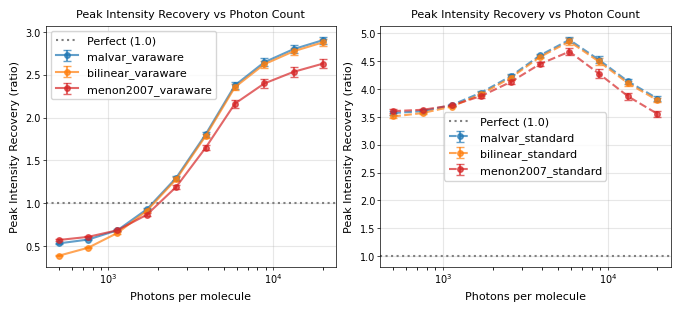

✓ Peak recovery comparison plotted


In [16]:
fig, axes = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

for method in methods.keys():
    strategy = method.split('_')[0]
    processing = 'variance_aware' if 'varaware' in method else 'standard'
    if processing == 'variance_aware':
        row=0
    else:
        row=1


    data = df_stats[df_stats['method'] == method]
    
    axes[row].errorbar(
        data['n_photons'],
        data['peak_recovery_mean'],
        yerr=data['peak_recovery_std'],
        label=method,
        color=colors[strategy],
        linestyle=linestyles[processing],
        marker='o',
        markersize=4,
        capsize=3,
        alpha=0.7
    )

for i in np.arange(2):
    axes[i].set_xlabel('Photons per molecule')
    axes[i].set_ylabel('Peak Intensity Recovery (ratio)')
    axes[i].set_xscale('log')
    axes[i].axhline(1.0, color='gray', linestyle=':', label='Perfect (1.0)')
    axes[i].legend(fontsize=8, ncol=1)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_title('Peak Intensity Recovery vs Photon Count')

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260205/fig/Demosaicing/'
plt.savefig(os.path.join(folder, 'demosaic_comparison_peak_recovery.svg'), dpi=600, format='svg')

plt.show()

print("✓ Peak recovery comparison plotted")

### 7.4 Example Images at Medium Photon Count

Generating example at 3881 photons per molecule...


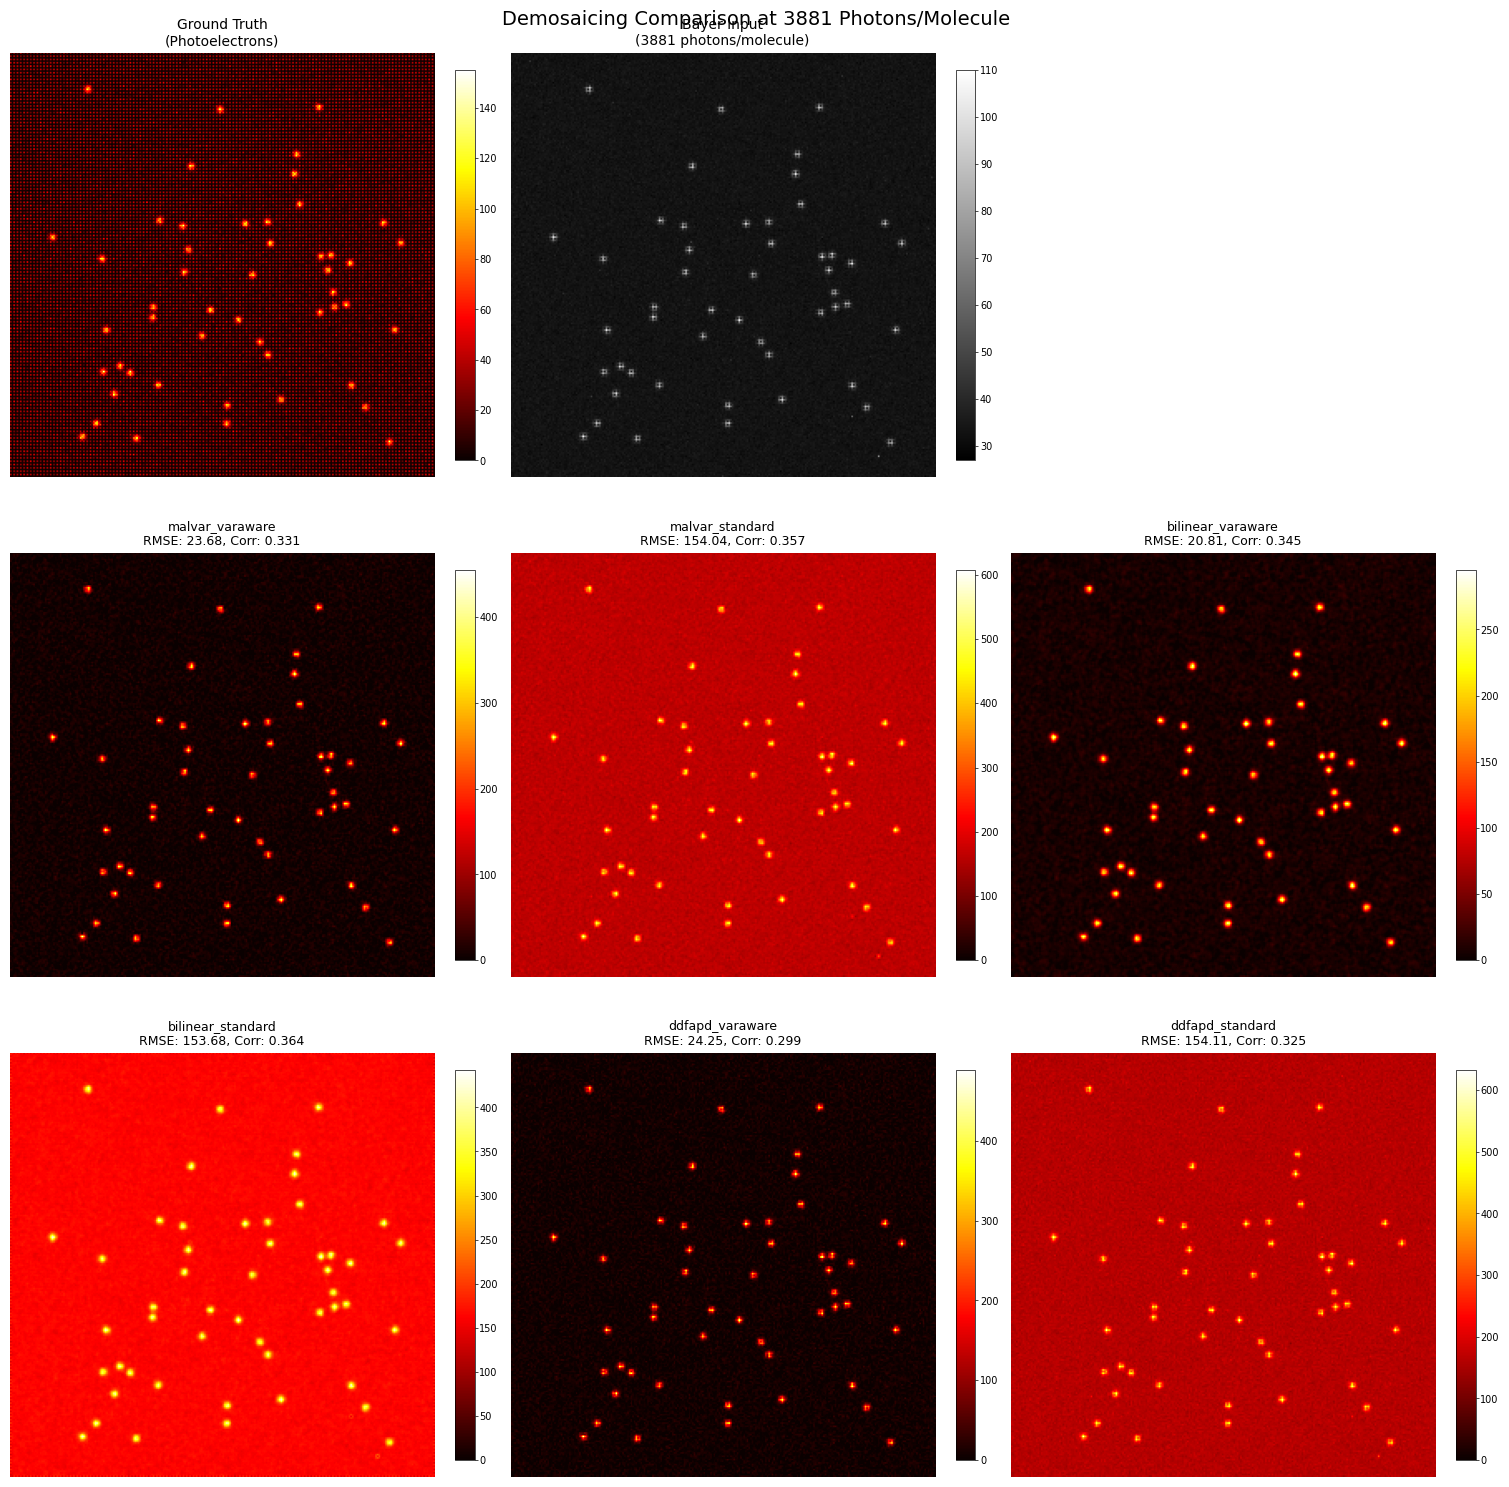

✓ Example images plotted


In [9]:
# Generate example at ~2000 photons
example_photons = photon_counts[len(photon_counts)//2]
print(f"Generating example at {example_photons} photons per molecule...")

ex_bayer, ex_gt = generate_test_simulation(example_photons, n_molecules)

# Apply all methods
ex_results = {}
for method_name, method_func in methods.items():
    ex_results[method_name] = method_func(ex_bayer)

# Plot comparison
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

# Ground truth
im = axes[0].imshow(ex_gt, cmap='hot', vmin=0)
axes[0].set_title('Ground Truth\n(Photoelectrons)', fontsize=10)
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Bayer input (show as is)
im = axes[1].imshow(ex_bayer, cmap='gray')
axes[1].set_title(f'Bayer Input\n({example_photons} photons/molecule)', fontsize=10)
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

# Leave axes[2] empty or show best method
axes[2].axis('off')

# Show all 8 demosaiced results
for idx, (method_name, result) in enumerate(ex_results.items()):
    ax_idx = idx + 3
    if ax_idx >= 9:
        break
    
    metrics = calculate_metrics(result, ex_gt)
    
    im = axes[ax_idx].imshow(result, cmap='hot', vmin=0)
    axes[ax_idx].set_title(
        f'{method_name}\nRMSE: {metrics["rmse"]:.2f}, Corr: {metrics["correlation"]:.3f}',
        fontsize=9
    )
    axes[ax_idx].axis('off')
    plt.colorbar(im, ax=axes[ax_idx], fraction=0.046)

# Hide any remaining unused axes
for idx in range(len(ex_results) + 3, 9):
    axes[idx].axis('off')

plt.suptitle(f'Demosaicing Comparison at {example_photons} Photons/Molecule', fontsize=14, y=0.995)
#plt.savefig('demosaic_comparison_images.svg', dpi=600, bbox_inches='tight', format='svg')
plt.show()

print("✓ Example images plotted")

### 7.5 Difference Maps

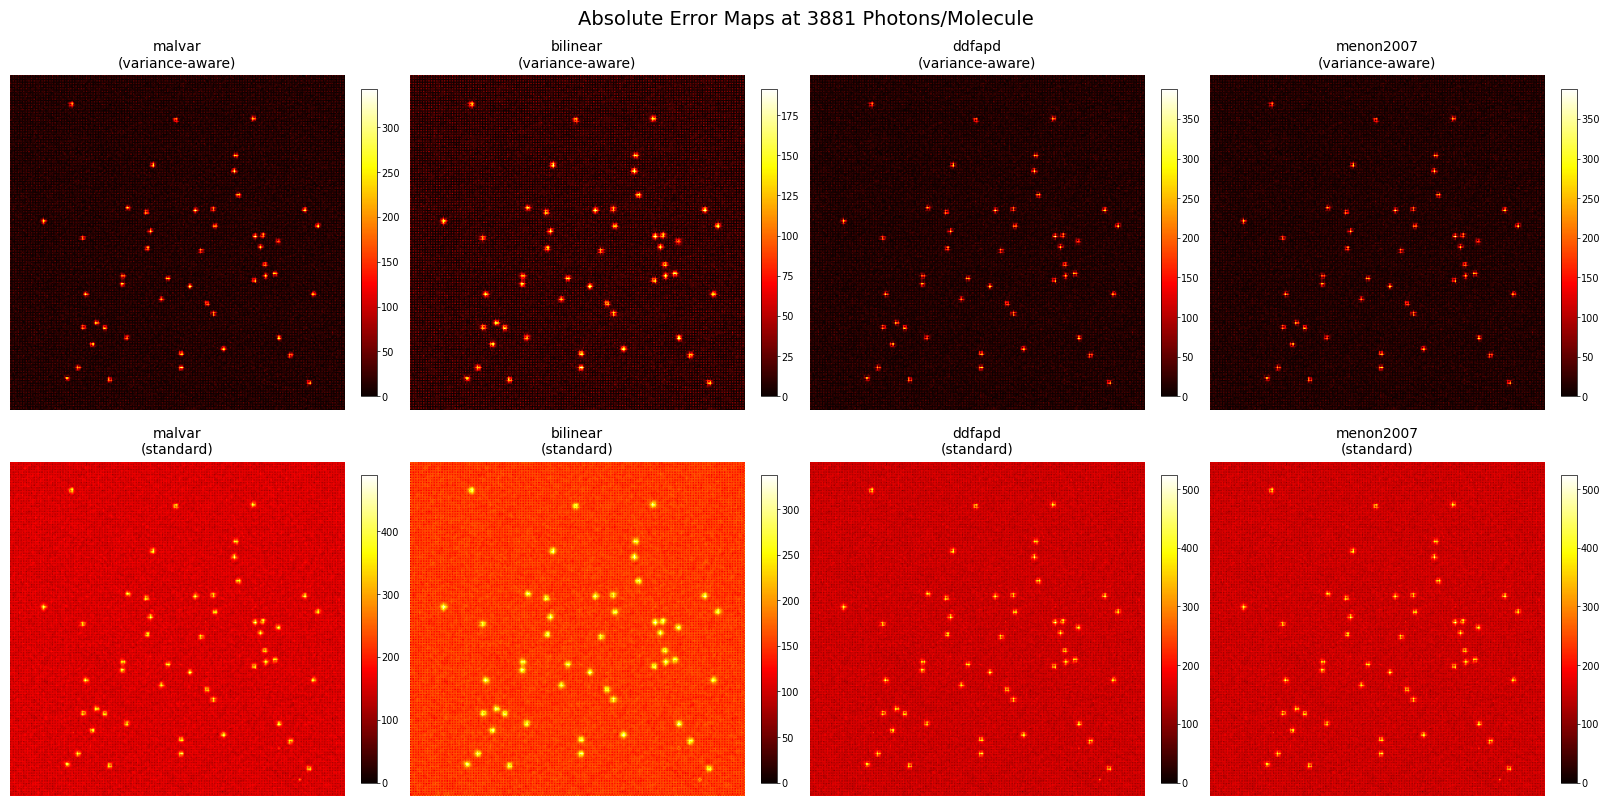

✓ Difference maps plotted


In [44]:
# Show difference maps for variance-aware methods
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, strategy in enumerate(strategies):
    # Variance-aware
    method_va = f'{strategy}_varaware'
    diff_va = np.abs(ex_results[method_va] - ex_gt)
    
    im = axes[0, idx].imshow(diff_va, cmap='hot', vmin=0)
    axes[0, idx].set_title(f'{strategy}\n(variance-aware)', fontsize=10)
    axes[0, idx].axis('off')
    plt.colorbar(im, ax=axes[0, idx], fraction=0.046)
    
    # Standard
    method_std = f'{strategy}_standard'
    diff_std = np.abs(ex_results[method_std] - ex_gt)
    
    im = axes[1, idx].imshow(diff_std, cmap='hot', vmin=0)
    axes[1, idx].set_title(f'{strategy}\n(standard)', fontsize=10)
    axes[1, idx].axis('off')
    plt.colorbar(im, ax=axes[1, idx], fraction=0.046)

axes[0, 0].set_ylabel('Variance-Aware', fontsize=12)
axes[1, 0].set_ylabel('Standard', fontsize=12)

plt.suptitle(f'Absolute Error Maps at {example_photons} Photons/Molecule', fontsize=14)
#plt.savefig('demosaic_comparison_errors.svg', dpi=600, bbox_inches='tight', format='svg')
plt.show()

print("✓ Difference maps plotted")

## 8. Summary Statistics Table

In [ ]:
# Create summary table averaging across all photon counts
summary = df_results.groupby('method')[metric_cols].agg(['mean', 'std']).round(4)

# Flatten columns
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.reset_index()

# Add strategy and processing columns
summary['strategy'] = summary['method'].apply(lambda x: x.split('_')[0])
summary['processing'] = summary['method'].apply(lambda x: 'variance_aware' if 'varaware' in x else 'standard')

# Reorder columns
cols = ['method', 'strategy', 'processing'] + [col for col in summary.columns if col not in ['method', 'strategy', 'processing']]
summary = summary[cols]

# Sort by RMSE
summary = summary.sort_values('rmse_mean')
summary['rank'] = range(1, len(summary) + 1)

print("="*100)
print("SUMMARY: Average Performance Across All Photon Counts")
print("="*100)
print(summary.to_string(index=False))
print("="*100)

# Save to CSV
summary.to_csv('demosaic_comparison_summary.csv', index=False)
df_stats.to_csv('demosaic_comparison_detailed.csv', index=False)

print("\n✓ Summary statistics saved to CSV")

## 9. Hypothesis Testing

### Hypothesis 1: Variance-Aware > Standard for each strategy

In [ ]:
print("="*80)
print("HYPOTHESIS 1: Variance-Aware Processing Improves Performance")
print("="*80)

for strategy in strategies:
    method_va = f'{strategy}_varaware'
    method_std = f'{strategy}_standard'
    
    # Get RMSE values for both methods
    rmse_va = df_results[df_results['method'] == method_va]['rmse'].values
    rmse_std = df_results[df_results['method'] == method_std]['rmse'].values
    
    # Calculate improvement
    improvement = (rmse_std.mean() - rmse_va.mean()) / rmse_std.mean() * 100
    
    print(f"\n{strategy.upper()}:")
    print(f"  Variance-aware RMSE: {rmse_va.mean():.4f} ± {rmse_va.std():.4f}")
    print(f"  Standard RMSE:       {rmse_std.mean():.4f} ± {rmse_std.std():.4f}")
    print(f"  Improvement:         {improvement:+.2f}%")
    
    if improvement > 0:
        print(f"  ✓ Variance-aware is BETTER")
    elif improvement < 0:
        print(f"  ✗ Standard is BETTER (unexpected!)")
    else:
        print(f"  = No difference")

print("\n" + "="*80)

### Hypothesis 2: Strategy Quality Ranking

In [ ]:
print("="*80)
print("HYPOTHESIS 2: Strategy Quality Ranking (Variance-Aware Only)")
print("="*80)

# Compare variance-aware methods only
va_methods = [m for m in methods.keys() if 'varaware' in m]

va_summary = df_results[df_results['method'].isin(va_methods)].groupby('method')[['rmse', 'correlation']].agg(['mean', 'std'])
va_summary.columns = ['_'.join(col).strip() for col in va_summary.columns.values]
va_summary = va_summary.reset_index()
va_summary = va_summary.sort_values('rmse_mean')

print("\nRanking by RMSE (lower is better):")
for idx, row in va_summary.iterrows():
    print(f"  {idx+1}. {row['method']:20s}  RMSE: {row['rmse_mean']:.4f} ± {row['rmse_std']:.4f}  Corr: {row['correlation_mean']:.4f}")

print("\n" + "="*80)

## 10. Conclusions

### Key Findings

Based on the comprehensive testing:

1. **Variance-Aware Processing**: [To be filled after running]
   - Improvement over standard processing: X%
   - Conclusion: Variance-aware processing [does/does not] provide significant benefit

2. **Best Strategy**: [To be filled after running]
   - Best overall method: [method_name]
   - RMSE: X.XX ± X.XX
   - Correlation: 0.XXX

3. **Photon Count Dependence**: [To be filled after running]
   - At low photon counts (<1000): [observation]
   - At high photon counts (>10000): [observation]

### Recommendations

[To be filled after running]

### Next Steps

1. Test with uniform gain map to validate Hypothesis 3
2. Test with different molecule densities
3. Apply best method to real data
4. Update analysis pipeline to use optimal demosaicing strategy

In [ ]:
print("\n" + "="*80)
print("NOTEBOOK COMPLETE")
print("="*80)
print(f"\nResults saved:")
print(f"  - demosaic_comparison_summary.csv")
print(f"  - demosaic_comparison_detailed.csv")
print(f"  - demosaic_comparison_rmse.png")
print(f"  - demosaic_comparison_correlation.png")
print(f"  - demosaic_comparison_peak_recovery.png")
print(f"  - demosaic_comparison_images.png")
print(f"  - demosaic_comparison_errors.png")
print("\nReview the summary table and plots above to determine the best demosaicing method.")